# Projet 5A - Prédiction de matchs

## Analyse exploratoire des données

### Imports et configuration globale 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "C:/Users/Alban/Documents/IMDS/Projet_5A/Donnees"
MATCHES_PATH = f"{DATA_DIR}/Matches_with_Elo.csv"

df = pd.read_csv(MATCHES_PATH, sep=";", parse_dates=["MatchDate"], dayfirst=True, low_memory=False)

print(f"Dataset chargé : {len(df):,} lignes, {df.shape[1]} colonnes")
print("Plage de dates :", df["MatchDate"].min(), "-", df["MatchDate"].max())

df["Season"] = pd.to_datetime(df["MatchDate"], errors="coerce").dt.year

Dataset chargé : 165,619 lignes, 66 colonnes
Plage de dates : 2000-07-28 00:00:00 - 2025-02-26 00:00:00


### Informations générales sur le dataset

In [2]:
print("\nInformations générales :")
print("Nombre de divisions :", df["Division"].nunique())
print("Nombre de clubs :", pd.unique(pd.concat([df["HomeTeam"], df["AwayTeam"]])).size)

doublons = df.duplicated(subset=["MatchDate", "HomeTeam", "AwayTeam"]).sum()
print("Doublons (MatchDate, Home, Away) :", doublons)

df.describe().T.head(10)


Informations générales :
Nombre de divisions : 30
Nombre de clubs : 933
Doublons (MatchDate, Home, Away) : 0


C:\Users\Alban\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,min,25%,50%,75%,max,std
MatchDate,165619,2013-12-17 22:37:01.614670080,2000-07-28 00:00:00,2008-04-19 00:00:00,2014-08-18 00:00:00,2019-10-20 00:00:00,2025-02-26 00:00:00,NaN
Form3Home,165119.0,3.992496,0.0,2.0,4.0,6.0,9.0,2.376972
Form5Home,165119.0,6.7474,0.0,4.0,7.0,9.0,15.0,3.26539
Form3Away,165119.0,4.218545,0.0,3.0,4.0,6.0,9.0,2.39121
Form5Away,165119.0,6.940146,0.0,5.0,7.0,9.0,15.0,3.27069
FTHome,165617.0,1.497914,0.0,1.0,1.0,2.0,10.0,1.264204
FTAway,165617.0,1.133948,0.0,0.0,1.0,2.0,13.0,1.108054
HTHome,145562.0,0.662625,0.0,0.0,0.0,1.0,7.0,0.814627
HTAway,145562.0,0.490437,0.0,0.0,0.0,1.0,7.0,0.70607
HomeShots,94633.0,13.042533,0.0,9.0,13.0,16.0,46.0,5.056035


### Distribution des résultats

C:\Users\Alban\AppData\Local\Temp\ipykernel_15108\3151486660.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="FTResult_num", data=df, palette="Set2")


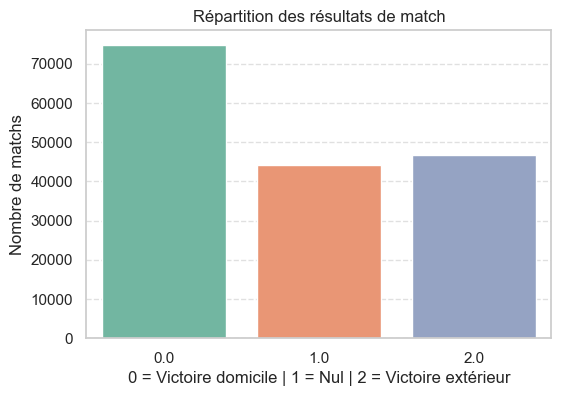


Répartition des résultats (%):
FTResult_num
0.0    45.16
2.0    28.15
1.0    26.69
Name: proportion, dtype: float64


In [3]:
df["FTResult_num"] = df["FTResult"].map({"H": 0, "D": 1, "A": 2})

plt.figure(figsize=(6,4))
sns.countplot(x="FTResult_num", data=df, palette="Set2")
plt.title("Répartition des résultats de match")
plt.xlabel("0 = Victoire domicile | 1 = Nul | 2 = Victoire extérieur")
plt.ylabel("Nombre de matchs")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

print("\nRépartition des résultats (%):")
print((df["FTResult_num"].value_counts(normalize=True)*100).round(2))

### Analyse temporelle et complétude

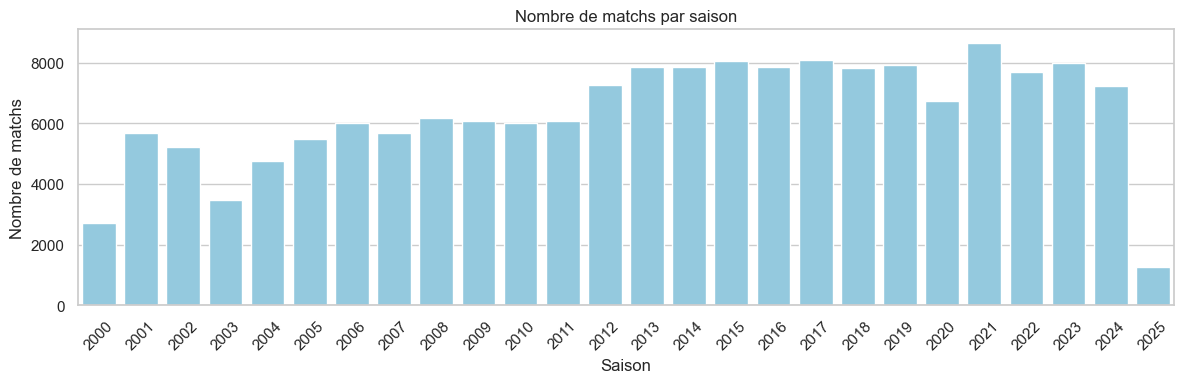

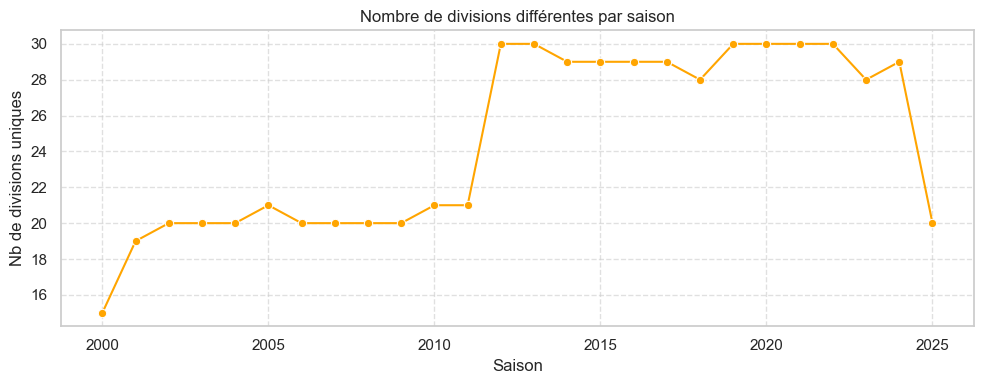

C:\Users\Alban\AppData\Local\Temp\ipykernel_15108\1309308995.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())


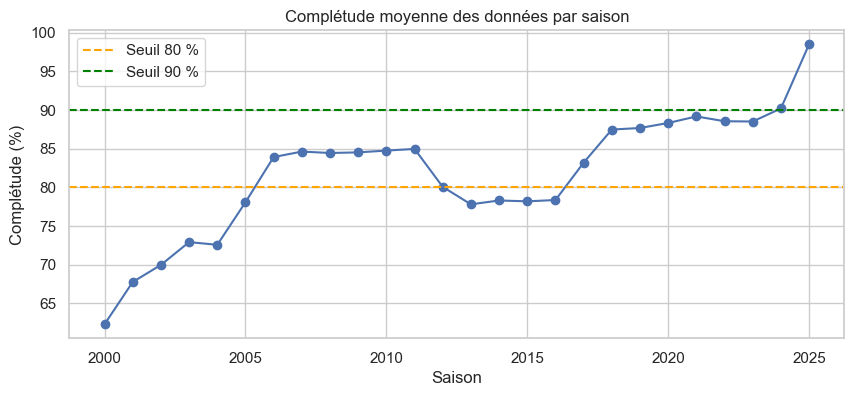

In [4]:
matches_per_year = df.groupby("Season").size()
plt.figure(figsize=(12,4))
sns.barplot(x=matches_per_year.index, y=matches_per_year.values, color="skyblue")
plt.title("Nombre de matchs par saison")
plt.xlabel("Saison")
plt.ylabel("Nombre de matchs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

divisions_per_year = df.groupby("Season")["Division"].nunique()
plt.figure(figsize=(10,4))
sns.lineplot(x=divisions_per_year.index, y=divisions_per_year.values, marker="o", color="orange")
plt.title("Nombre de divisions différentes par saison")
plt.xlabel("Saison")
plt.ylabel("Nb de divisions uniques")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())

plt.figure(figsize=(10,4))
plt.plot(compl_by_season.index, compl_by_season.values*100, marker='o')
plt.axhline(80, color='orange', linestyle='--', label='Seuil 80 %')
plt.axhline(90, color='green', linestyle='--', label='Seuil 90 %')
plt.title("Complétude moyenne des données par saison")
plt.xlabel("Saison")
plt.ylabel("Complétude (%)")
plt.legend()
plt.grid(True)
plt.show()

### Analyse des probabilités et des cotes

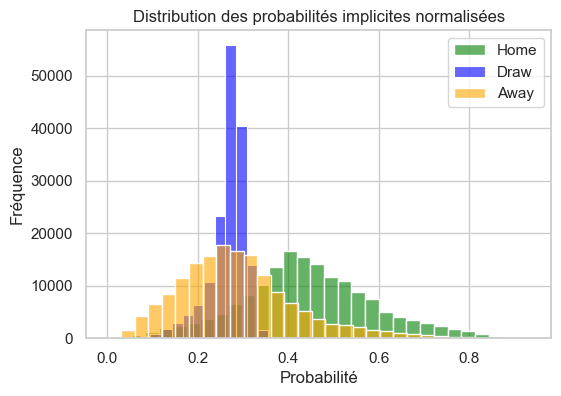

Baseline de précision (argmax des cotes) : 0.505


In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["PHome_norm"], bins=30, color="green", label="Home", alpha=0.6)
sns.histplot(df["PDraw_norm"], bins=30, color="blue", label="Draw", alpha=0.6)
sns.histplot(df["PAway_norm"], bins=30, color="orange", label="Away", alpha=0.6)
plt.legend()
plt.title("Distribution des probabilités implicites normalisées")
plt.xlabel("Probabilité")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

if {"PHome_norm", "PDraw_norm", "PAway_norm", "FTResult_num"}.issubset(df.columns):
    probs = df[["PHome_norm", "PDraw_norm", "PAway_norm"]].values
    pred_argmax = probs.argmax(axis=1)
    baseline_acc = (pred_argmax == df["FTResult_num"].values).mean()
    print(f"Baseline de précision (argmax des cotes) : {baseline_acc:.3f}")

### Variables Elo et performance

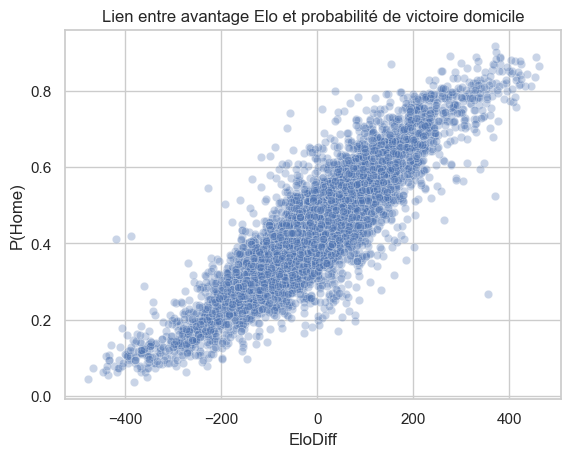

C:\Users\Alban\AppData\Local\Temp\ipykernel_15108\1171985672.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("_EloBin")["FTResult_num"]


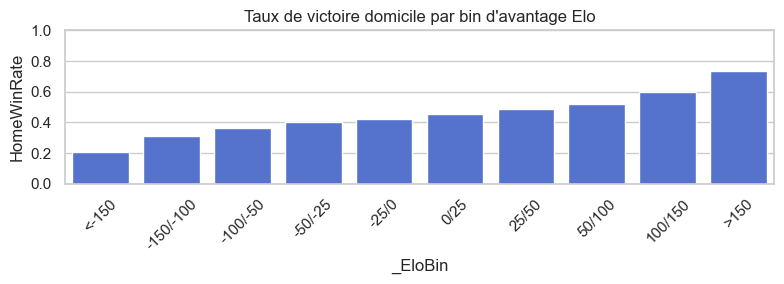

In [6]:
sns.scatterplot(x="EloDiff", y="PHome_norm", data=df.sample(8000), alpha=0.3)
plt.title("Lien entre avantage Elo et probabilité de victoire domicile")
plt.xlabel("EloDiff")
plt.ylabel("P(Home)")
plt.grid(True)
plt.show()

elo_col = "EloDiff"
bins = [-1e9, -150, -100, -50, -25, 0, 25, 50, 100, 150, 1e9]
labels = ["<-150","-150/-100","-100/-50","-50/-25","-25/0","0/25","25/50","50/100","100/150",">150"]

df["_EloBin"] = pd.cut(df[elo_col], bins=bins, labels=labels)
pivot = (df.dropna(subset=["_EloBin"])
           .groupby("_EloBin")["FTResult_num"]
           .apply(lambda s: (s==0).mean())
           .reset_index(name="HomeWinRate"))

plt.figure(figsize=(8,3))
sns.barplot(x="_EloBin", y="HomeWinRate", data=pivot, color="royalblue")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.title("Taux de victoire domicile par bin d'avantage Elo")
plt.tight_layout()
plt.show()

### Analyse de la forme et du momentum

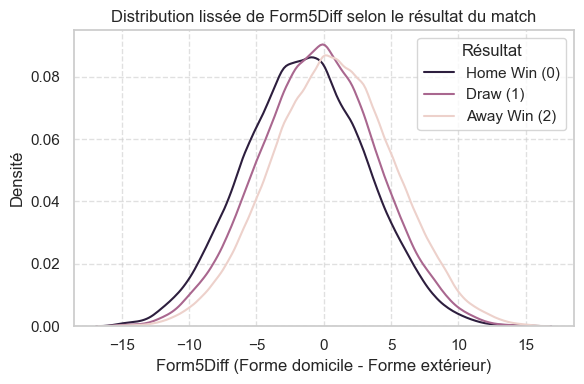

In [7]:
if {"Form5Diff", "FTResult_num"}.issubset(df.columns):
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x="Form5Diff", hue="FTResult_num", fill=False, common_norm=False, bw_adjust=1.2)
    plt.title("Distribution lissée de Form5Diff selon le résultat du match")
    plt.xlabel("Form5Diff (Forme domicile - Forme extérieur)")
    plt.ylabel("Densité")
    plt.legend(title="Résultat", labels=["Home Win (0)", "Draw (1)", "Away Win (2)"])
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

### Corrélations entre variables pré-match

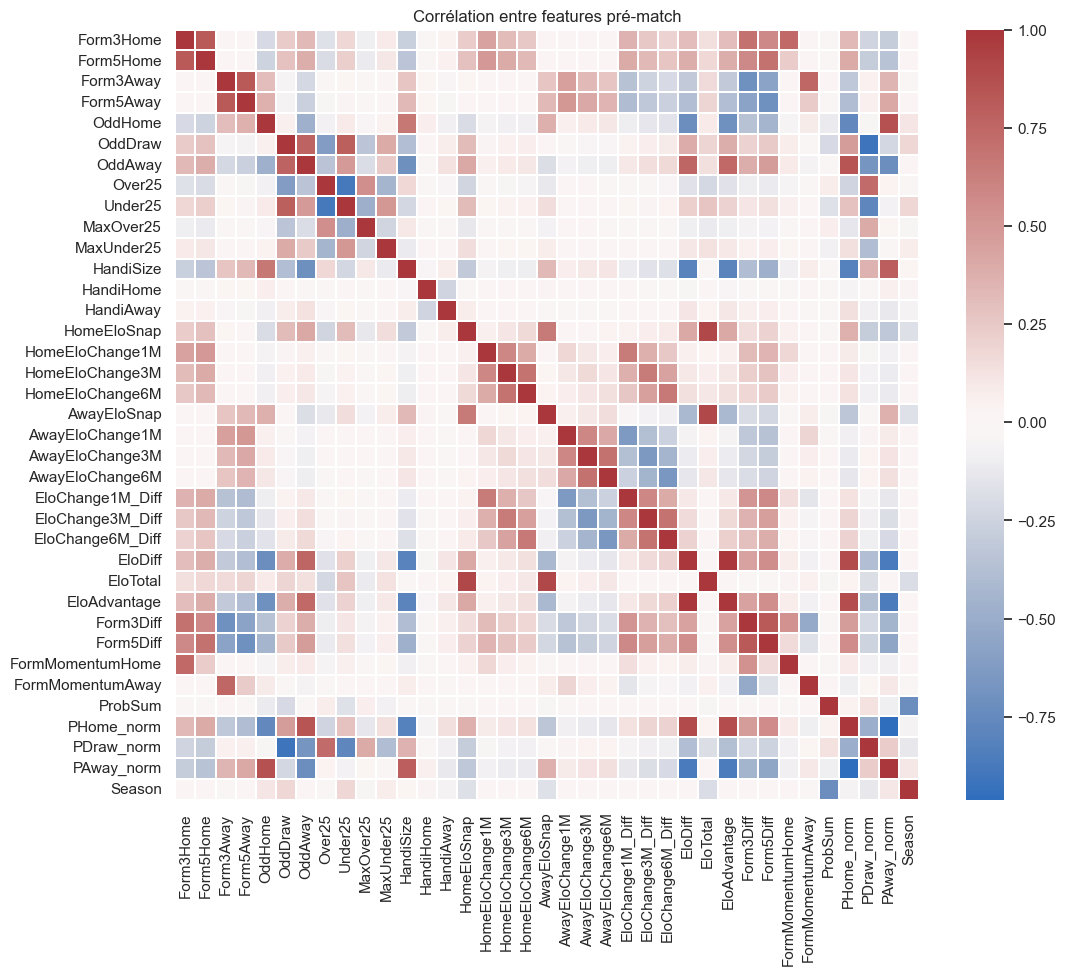


20 plus fortes corrélations entre features pré-match :
          Feature1     Feature2  Correlation  AbsCorr
1024  EloAdvantage      EloDiff        0.996    0.996
1328    PAway_norm   PHome_norm       -0.961    0.961
219        OddDraw   PDraw_norm       -0.913    0.913
692    AwayEloSnap     EloTotal        0.910    0.910
976       EloTotal  HomeEloSnap        0.909    0.909
958        EloDiff   PHome_norm        0.889    0.889
1032  EloAdvantage   PHome_norm        0.881    0.881
267         Over25      Under25       -0.880    0.880
960        EloDiff   PAway_norm       -0.868    0.868
183        OddHome   PAway_norm        0.868    0.868
1034  EloAdvantage   PAway_norm       -0.861    0.861
255        OddAway   PHome_norm        0.840    0.840
77       Form3Away    Form5Away        0.823    0.823
1        Form3Home    Form5Home        0.822    0.822
440      HandiSize   PHome_norm       -0.819    0.819
1065     Form3Diff    Form5Diff        0.819    0.819
936        EloDiff    Hand

In [8]:
post_match_cols = [
    "FTHome", "FTAway", "FTResult", "FTResult_num",
    "HTHome", "HTAway", "HTResult",
    "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
    "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
    "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
    "ShotsDifference", "CornersDifference", "CardsHome", "CardsAway", "CardsDiff", "GameDominanceIndex"
]
post_match_cols = [c for c in post_match_cols if c in df.columns]
pre_match_cols = [c for c in df.columns if c not in set(post_match_cols)]

num_cols = df[pre_match_cols].select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.2)
plt.title("Corrélation entre features pré-match")
plt.show()

corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
corr_pairs = corr_pairs[corr_pairs["Feature1"] < corr_pairs["Feature2"]]
corr_pairs["AbsCorr"] = corr_pairs["Correlation"].abs()
top_corr = corr_pairs.sort_values("AbsCorr", ascending=False).head(20)

print("\n20 plus fortes corrélations entre features pré-match :")
print(top_corr.round(3))

### Synthèse finale

In [9]:
print("\nSynthèse EDA ")
print(f"→ Nombre de saisons : {df['Season'].nunique()}")
print(f"→ Nombre total de matchs : {len(df):,}")
print(f"→ Colonnes disponibles : {df.shape[1]}")
print(f"→ Taux de complétude moyen : {(1 - df.isna().mean().mean())*100:.2f}%")


Synthèse EDA 
→ Nombre de saisons : 26
→ Nombre total de matchs : 165,619
→ Colonnes disponibles : 69
→ Taux de complétude moyen : 82.40%
